In [1]:
def readInputAsArray(fileName):
    with open(fileName, 'r') as myfile:
        data = myfile.readlines()

    # Strip newline
    for i in range(0, len(data)):
        data[i] = data[i].rstrip()
    # print(data)
    return data

In [33]:
performance=readInputAsArray('/Users/yibeijia/Downloads/data/train_model1_out')
# performance=readInputAsArray('/Users/yibeijia/Downloads/data/train_model2_out')
e = 0
E = []
avgs=[]
start = 1
total = 0
for i in performance:

    i = i.split()
#     print( i[0])
    if start == 1:
        val = float(i[7][:6])
#         print(val)
        total += val
        start = 0
    
    # New Epoch
    elif i[0] == '1/1944':
        avg = total / 1944;
        avgs = avgs + [avg]
        total = 0
        e+=1
        E+=[e]
#         print("epoch", e)
#         print(avg)
        
    else:
        val = float(i[7][:6])
#         print(val)
        total += val
# The last epoch
avg = total / 1944;
avgs = avgs + [avg]
e+=1
E+=[e]
print("epoch", e)
print(avg)
print (avgs)
print (len(avgs))

epoch 32
0.010762962962963047
[0.21210817901234563, 0.13540401234567917, 0.09306193415637848, 0.06711985596707808, 0.05492227366255185, 0.05369804526748951, 0.04416538065843564, 0.040796244855967174, 0.03749825102880662, 0.035306481481481626, 0.034545318930041216, 0.031134567901234436, 0.028711728395061722, 0.029238168724279288, 0.027008281893004218, 0.026530195473251014, 0.024674999999999864, 0.02372587448559713, 0.02292865226337442, 0.02208503086419742, 0.021893930041152167, 0.019717746913580362, 0.020001440329217857, 0.01975951646090535, 0.01849120370370372, 0.01843482510288086, 0.018132458847736583, 0.016280864197531206, 0.015189351851851612, 0.015466872427983743, 0.014273713991769254, 0.010762962962963047]
32


In [34]:
performance=readInputAsArray('/Users/yibeijia/Downloads/data/test_out3')
# performance=readInputAsArray('/Users/yibeijia/Downloads/data/val_loss_model2')
e = 0
E = []
avgs_val=[]
for i in performance:
    i = i.split()
    avgs_val += [float(i[1])]

print (avgs_val)
print (len(avgs_val))

[0.1819, 0.1539, 0.0958, 0.0746, 0.0856, 0.0578, 0.0592, 0.0505, 0.0483, 0.0452, 0.051, 0.046, 0.0439, 0.0547, 0.0423, 0.0505, 0.0431, 0.0431, 0.0428, 0.0447, 0.0422, 0.0537, 0.0461, 0.0432, 0.045, 0.0427, 0.0419, 0.0471, 0.0551, 0.0428, 0.0432]
31


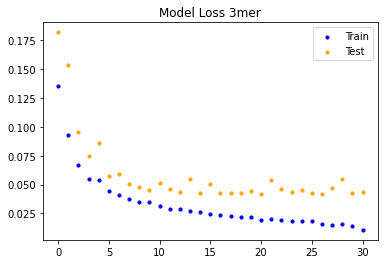

In [36]:
import matplotlib.pyplot as plt

plt.scatter(range((len(avgs_val))), avgs[1:], s=10, color='blue', label='Train')
# plt.scatter(range((len(avgs_val))), avgs, s=10, color='blue', label='Train')
plt.scatter(range(len(avgs_val)), avgs_val, s=10, color='orange', label='Test')
plt.legend()
plt.title('Model Loss 3mer')
plt.savefig("ModelLoss_3mer.jpg")

In [30]:
test_out = '/Users/yibeijia/Downloads/data/test_copy.out'
# test_out = '/Users/yibeijia/Downloads/data/test_model2.out'
test=readInputAsArray(test_out)        

In [23]:
true = []
pred = []

for i in test:
    line = i.split()
    for k in line:
        score = k.split("=")
        if score[0]=="TrueLabel":
#             print(score[1][1])
            true += [int(score[1][1])]
        if score[0]=="Predicted":
#             print(score[0][1])
            if (float(score[1][1:len(score[1])-1]) > 0.5):
                pred += [1]
            else:
                pred += [0]  

In [26]:
pred[:5]

[1, 0, 1, 0, 1]

In [25]:
true[:5]

[1, 0, 1, 0, 1]

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(true, pred)

0.9467868223609738

In [28]:
from sklearn.metrics import precision_score
precision_score(true, pred)

0.9349932270180408

In [29]:
from sklearn.metrics import recall_score
recall_score(true, pred)

0.9475915089320954